<a href="https://colab.research.google.com/github/glisserok/grigoriyvolkov/blob/main/%D0%9F%D1%96%D0%B4%D1%81%D1%83%D0%BC%D0%BA%D0%BE%D0%B2%D0%B0_%D0%BA%D0%BE%D0%BD%D1%82%D1%80%D0%BE%D0%BB%D1%8C%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%D0%9A%D0%A1%D0%92%D0%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Перші 5 рядків:
   rank                    Youtuber  subscribers   video views  \
0     1                    T-Series    245000000  2.280000e+11   
1     2              YouTube Movies    170000000  0.000000e+00   
2     3                     MrBeast    166000000  2.836884e+10   
3     4  Cocomelon - Nursery Rhymes    162000000  1.640000e+11   
4     5                   SET India    159000000  1.480000e+11   

           category                       Title  uploads        Country  \
0             Music                    T-Series    20082          India   
1  Film & Animation               youtubemovies        1  United States   
2     Entertainment                     MrBeast      741  United States   
3         Education  Cocomelon - Nursery Rhymes      966  United States   
4             Shows                   SET India   116536          India   

  Abbreviation   channel_type  ...  subscribers_for_last_30_days  \
0           IN          Music  ...                     2000000.0   


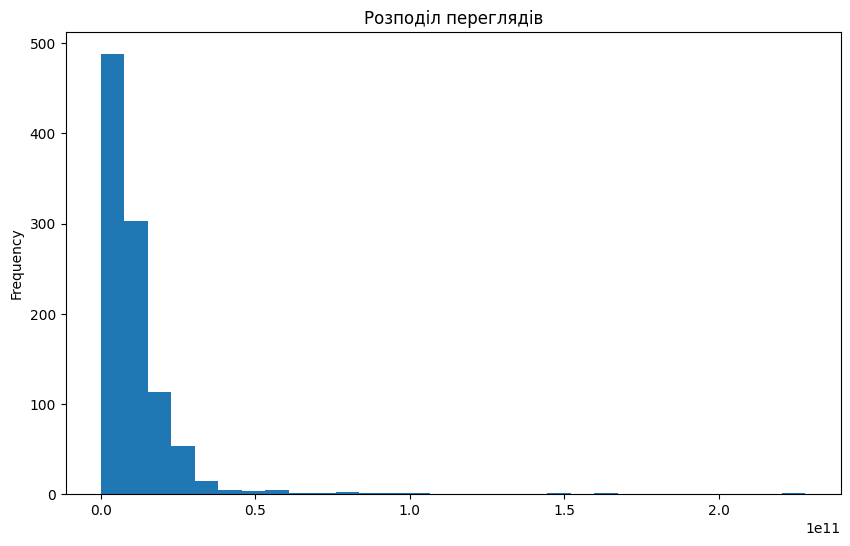


Макс. переглядів: 228000000000.0
Мін. переглядів: 0.0
Сер. переглядів: 11039537052.03819

Країна з найбільшою кількістю завантажень: India


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Global YouTube Statistics.csv', encoding='latin-1')

print("Перші 5 рядків:")
print(df.head())

print(f"\nРозмір датасету: {df.shape}")

print("\nПропуски по стовпцях:")
print(df.isna().sum())

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean()).astype(float)

print(f"\nПропуски після обробки (числові): {df[numeric_cols].isna().sum().sum()}")

print(f"\nКількість унікальних країн: {df['Country'].nunique()}")

plt.figure(figsize=(10, 6))
df['video views'].plot(kind='hist', bins=30, title='Розподіл переглядів')
plt.show()

print(f"\nМакс. переглядів: {df['video views'].max()}")
print(f"Мін. переглядів: {df['video views'].min()}")
print(f"Сер. переглядів: {df['video views'].mean()}")

top_country = df.groupby('Country')['uploads'].sum().idxmax()
print(f"\nКраїна з найбільшою кількістю завантажень: {top_country}")


Інформація про датасет покупок:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900

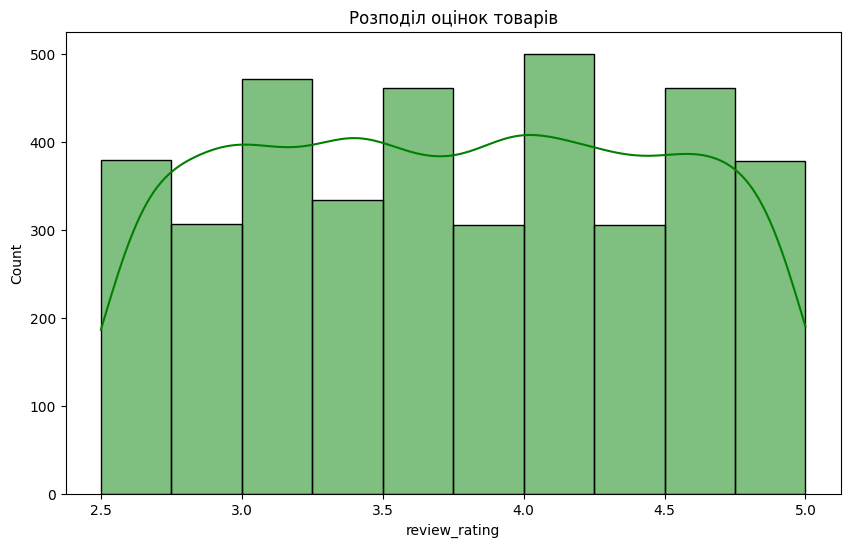

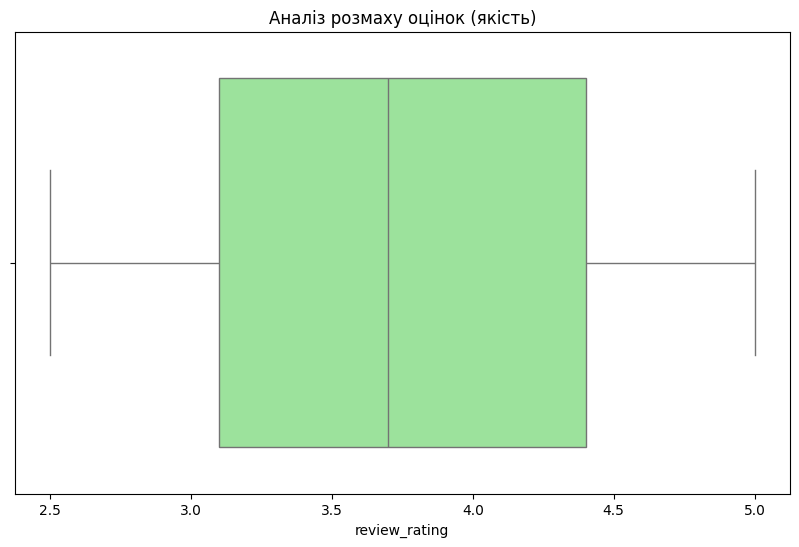

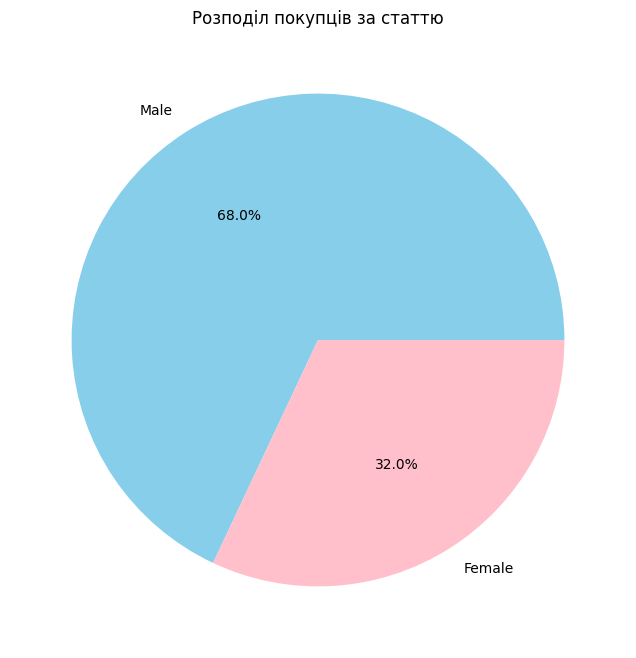

/tmp/ipykernel_28927/538299430.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_shop, x='gender', palette='pastel')


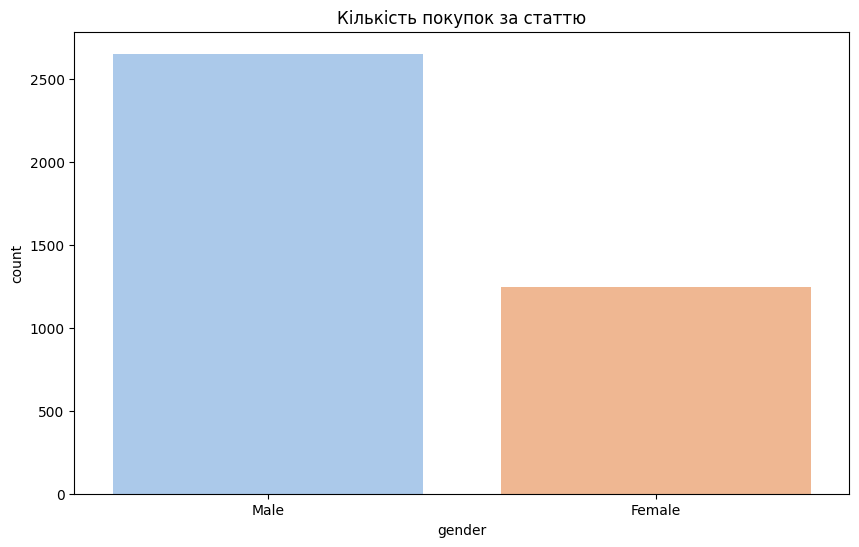

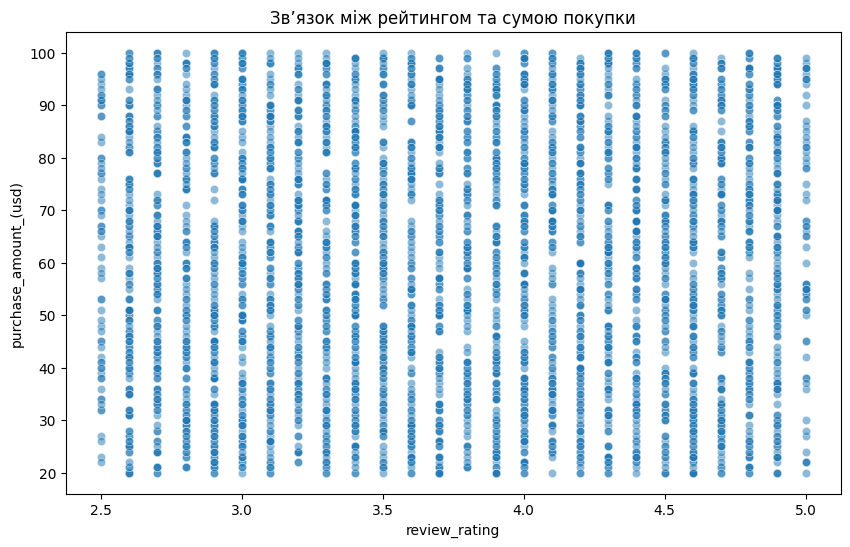

In [ ]:
df_shop = pd.read_csv('shopping_trends.csv')

print("\nІнформація про датасет покупок:")
df_shop.info()

df_shop.columns = [col.lower().replace(' ', '_') for col in df_shop.columns]
print("\nОновлені назви стовпців:", df_shop.columns.tolist())

plt.figure(figsize=(10, 6))
sns.histplot(df_shop['review_rating'], bins=10, kde=True, color='green')
plt.title('Розподіл оцінок товарів')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=df_shop['review_rating'], color='lightgreen')
plt.title('Аналіз розмаху оцінок (якість)')
plt.show()

plt.figure(figsize=(8, 8))
df_shop['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'pink'])
plt.title('Розподіл покупців за статтю')
plt.ylabel('')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df_shop, x='gender', palette='pastel')
plt.title('Кількість покупок за статтю')
plt.show()

amount_col = 'purchase_amount_(usd)' if 'purchase_amount_(usd)' in df_shop.columns else 'purchase_amount'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_shop, x='review_rating', y=amount_col, alpha=0.5)
plt.title('Зв’язок між рейтингом та сумою покупки')
plt.show()

In [1]:
import altair as alt

from vega_datasets import data
weather = data.seattle_weather()

chart1 = alt.Chart(weather).mark_bar(cornerRadiusTopLeft=10, cornerRadiusTopRight=10).encode(
    x=alt.X('weather:N', sort='-y'),
    y='count()',
    color='weather:N'
).properties(title='Гістограма типів погоди')

barley = data.barley()
chart2 = alt.Chart(barley).transform_filter(alt.datum.year == 1931).mark_bar().encode(
    x='yield:Q',
    y=alt.Y('variety:N', sort='-x'),
    color='site:N'
).properties(title='Врожайність ячменю 1931')

unemp = data.unemployment_across_industries.url
chart3 = alt.Chart(unemp).mark_area().encode(
    x='date:T',
    y=alt.Y('sum(count):Q', stack='center', axis=None),
    color='series:N'
).interactive().properties(title='Потоковий граф безробіття')

chart1.display()
chart2.display()
chart3.display()

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)